# Project Assignment 4: Plotting and Visualization

**Objective:**
In the previous assignment, you applied advanced data wrangling techniques. You will now create visualizations to conduct exploratory analysis on your data. 

**Guidelines:**
* **Exploratory Focus:** Generate four distinct visualizations that help you understand the distributions, relationships, or anomalies within your data.
* **Tool Requirement:** You may use Matplotlib, Pandas, or Seaborn for your plots. You are encouraged to use at least two different libraries.
* **Formatting:** Every plot must include a clear title, an x-axis label, and a y-axis label.
* **Justification and Findings:** For each visualization, you must explain why you chose that specific plot type for your variables and state exactly what the plot indicates about the data.

In [2]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load your PROCESSED dataset (the CSV you saved at the end of PA3)
df_clean = pd.read_csv('../data/project_data_processed.csv')
df_clean.head()
df_clean.info()
df_clean.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              50000 non-null  int64  
 1   order_date            50000 non-null  str    
 2   product_id            50000 non-null  int64  
 3   product_category      50000 non-null  str    
 4   price                 50000 non-null  float64
 5   discount_percent      50000 non-null  int64  
 6   quantity_sold         50000 non-null  int64  
 7   customer_region       50000 non-null  str    
 8   payment_method        50000 non-null  str    
 9   rating                50000 non-null  float64
 10  review_count          50000 non-null  int64  
 11  discounted_price      50000 non-null  float64
 12  total_revenue         50000 non-null  float64
 13  order_month           50000 non-null  int64  
 14  payment_method_clean  50000 non-null  str    
dtypes: float64(4), int64(6), str(5

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,order_month,payment_method_clean
count,50000.000000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0000,50000
unique,NaN,730,NaN,6,NaN,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,5
top,NaN,2023-10-19,NaN,Beauty,NaN,NaN,NaN,Asia,Wallet,NaN,NaN,NaN,NaN,NaN,Wallet
freq,NaN,93,NaN,8465,NaN,NaN,NaN,12526,10106,NaN,NaN,NaN,NaN,NaN,10106
mean,25000.500000,NaN,2986.848740,NaN,252.507260,13.340700,2.999400,NaN,NaN,2.996316,249.329280,218.886566,657.331475,6.5044,NaN
std,14433.901067,NaN,1156.374535,NaN,143.025544,9.850694,1.415401,NaN,NaN,1.154295,144.251981,127.317681,526.223968,3.4360,NaN
min,1.000000,NaN,1000.000000,NaN,5.010000,0.000000,1.000000,NaN,NaN,1.000000,0.000000,3.530000,3.840000,1.0000,NaN
25%,12500.750000,NaN,1983.000000,NaN,127.840000,5.000000,2.000000,NaN,NaN,2.000000,125.000000,109.680000,240.320000,4.0000,NaN
50%,25000.500000,NaN,2983.000000,NaN,252.970000,10.000000,3.000000,NaN,NaN,3.000000,250.000000,215.805000,505.410000,7.0000,NaN
75%,37500.250000,NaN,3989.000000,NaN,376.335000,20.000000,4.000000,NaN,NaN,4.000000,374.000000,322.702500,968.970000,9.0000,NaN


## Part 1: Visualization 1 (1.0 Point)

Generate your first exploratory visualization.

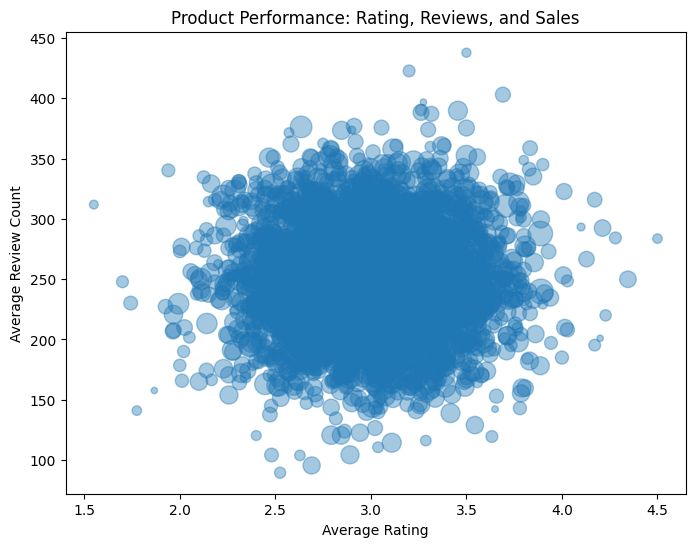

In [23]:
# TODO: Create your first plot
# TODO: Add a title, x-axis label, and y-axis label
# plt.show()

product_perf = (
    df_clean.groupby("product_id")
    .agg(
        avg_rating=("rating", "mean"),
        avg_reviews=("review_count", "mean"),
        total_sales=("total_revenue", "sum")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(
    product_perf["avg_rating"],
    product_perf["avg_reviews"],
    s=product_perf["total_sales"] / 50,  # scale bubble size
    alpha=0.4
)

ax.set_title("Product Performance: Rating, Reviews, and Sales")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Average Review Count")

plt.show()

**Reason for Selection:**
*Double click here to edit. Explain why this specific plot type is effective for the data variables you selected.*

**Analytical Finding:**
*Double click here to edit. State what this plot reveals about your data.*

## Part 2: Visualization 2 (1.0 Point)

Generate your second exploratory visualization. Ensure it shows a different relationship or distribution than Visualization 1.

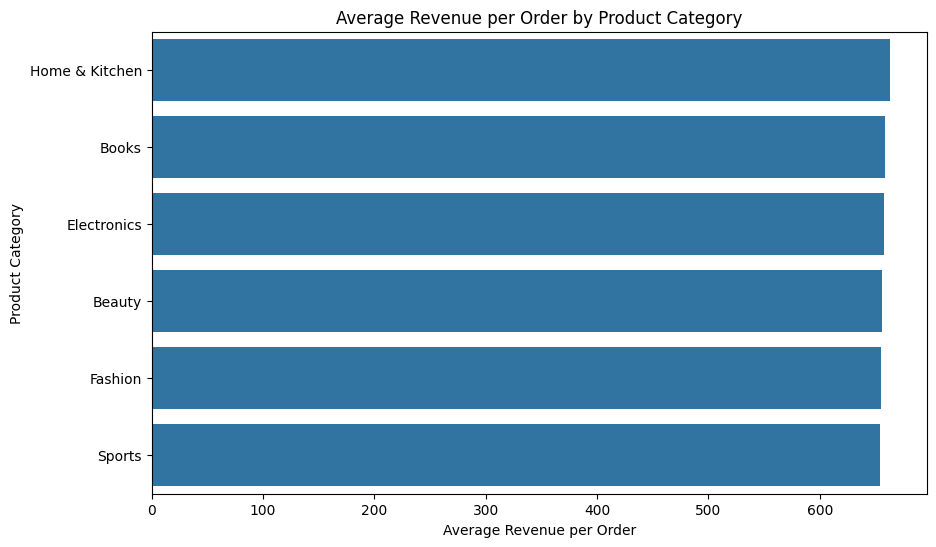

In [18]:
# TODO: Create your second plot
# TODO: Add a title, x-axis label, and y-axis label
# plt.show()
category_avg_rev = (
    df_clean.groupby("product_category")["total_revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(data=category_avg_rev,
            x="total_revenue",
            y="product_category",
            ax=ax)

ax.set_title("Average Revenue per Order by Product Category")
ax.set_xlabel("Average Revenue per Order")
ax.set_ylabel("Product Category")

plt.show()


**Reason for Selection:**
*Double click here to edit. Explain why this specific plot type is effective for the data variables you selected.*

**Analytical Finding:**
*Double click here to edit. State what this plot reveals about your data.*

## Part 3: Visualization 3 (1.0 Point)

Generate your third exploratory visualization.

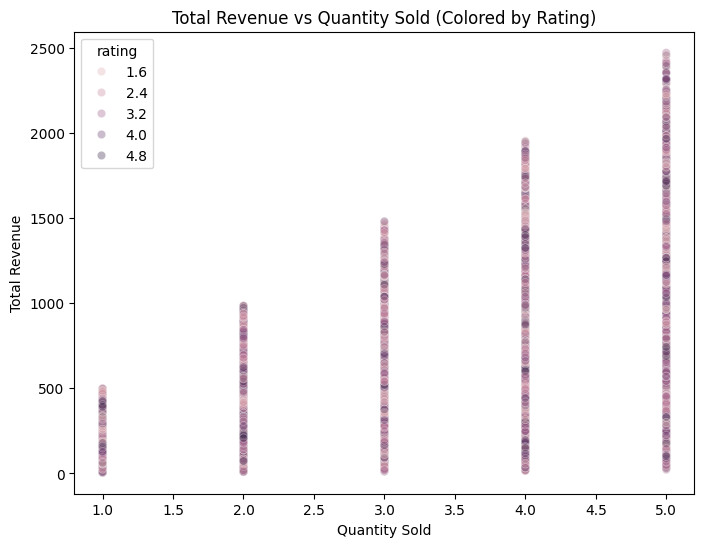

In [24]:
# TODO: Create your third plot
# TODO: Add a title, x-axis label, and y-axis label
# plt.show()
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=df_clean.sample(8000, random_state=0),
    x="quantity_sold",
    y="total_revenue",
    hue="rating",
    alpha=0.35,
    ax=ax
)

ax.set_title("Total Revenue vs Quantity Sold (Colored by Rating)")
ax.set_xlabel("Quantity Sold")
ax.set_ylabel("Total Revenue")

plt.show()

**Reason for Selection:**
*Double click here to edit. Explain why this specific plot type is effective for the data variables you selected.*

**Analytical Finding:**
*Double click here to edit. State what this plot reveals about your data.*

## Part 4: Visualization 4 (1.0 Point)

Generate your fourth exploratory visualization.

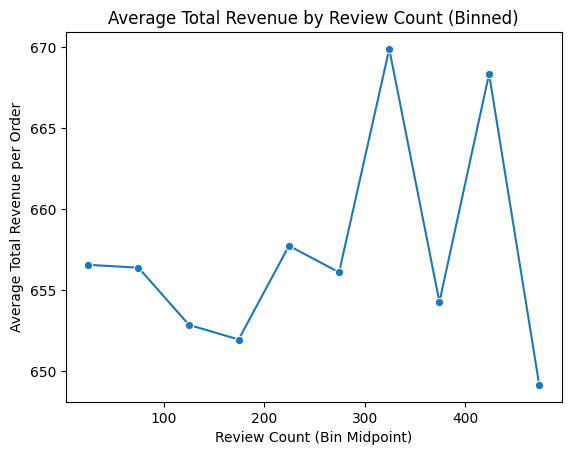

In [21]:
# TODO: Create your fourth plot
# TODO: Add a title, x-axis label, and y-axis label
# plt.show()
# Create bins based on review count
df_clean["review_bin"] = pd.qcut(df_clean["review_count"], q=10, duplicates="drop")


trend = (
    df_clean.groupby("review_bin")["total_revenue"]
    .mean()
    .reset_index()
)


trend["bin_mid"] = trend["review_bin"].apply(lambda x: x.mid)


fig, ax = plt.subplots()

sns.lineplot(data=trend,
             x="bin_mid",
             y="total_revenue",
             marker="o",
             ax=ax)

ax.set_title("Average Total Revenue by Review Count (Binned)")
ax.set_xlabel("Review Count (Bin Midpoint)")
ax.set_ylabel("Average Total Revenue per Order")

plt.show()

**Reason for Selection:**
*Double click here to edit. Explain why this specific plot type is effective for the data variables you selected.*

**Analytical Finding:**
*Double click here to edit. State what this plot reveals about your data.*

## Part 5: Final Reflection on your Research Question (1.0 Point)

**Implications for your research questions:**

*Double-click here to edit. State how the findings from your exploratory visualizations inform the research questions you proposed in Project Assignment 1 and Lab 5. Cite specific results from the graphs generated above to support your statements. Please indicate how these findings, support your initial analytical work intent or whether you might need to update your approach and how.*

Average Revenue Per Order by Product Category (Bar Chart)

A horizontal bar chart was used to compare average revenue per order across product categories. This visualization is appropriate because product category is categorical and revenue is continuous, allowing direct performance comparison.

The results show that all categories are clustered closely between approximately 630 and 660 in average revenue per order. No category meaningfully outperforms the others. This suggests that category alone is not a major driver of per-order revenue performance.

Product-Level Bubble Chart: Rating, Reviews, and Sales

This visualization aggregates data at the product level to reduce noise. Average rating and average review count are plotted, with total sales represented by bubble size. 

The graph shows that most products cluster between ratings of roughly 2.5–3.5 and moderate review counts. Larger revenue bubbles are distributed throughout this cluster rather than concentrated among the highest-rated and most-reviewed products. This indicates that strong reputation metrics do not consistently translate into substantially higher total sales.

Total Revenue vs Quantity Sold (Colored by Rating)

This scatter plot evaluates whether rating affects the relationship between quantity sold and revenue. Since revenue is directly linked to quantity, coloring by rating helps identify whether higher-rated products generate disproportionately higher revenue.

The results show a strong mechanical relationship between quantity and revenue, but ratings are spread evenly across all quantity levels. There is no visible pattern suggesting that higher ratings amplify revenue beyond unit sales.

Average Total Revenue by Review Count (Binned)

Review counts were grouped into bins to reduce overplotting and reveal trends. A line plot of average revenue per bin was used to assess whether revenue increases with review activity.

The trend line is relatively flat, ranging narrowly around 650–670. There is no consistent upward slope as review count increases. This suggests that review volume is not strongly associated with higher revenue per order in this dataset.



Initially, I expected customer engagement metrics such as ratings and review counts to have a meaningful impact on sales performance. Based on common assumptions in e-commerce analysis, higher ratings and greater review volume are often associated with stronger consumer trust and then in higher sales. I anticipated observing a clear positive relationship between these and revenue outcomes.

However, the visualizations do not strongly support that expectation. The binned review count analysis shows a relatively flat trend (small spikes) in average revenue per order, indicating that higher review volumes do not consistently correspond to that much greater revenue. Similarly, the product-level bubble chart does not reveal a concentration of larger total sales among the highest-rated and most-reviewed products. While ratings and review counts vary across products, revenue appears broadly dispersed rather than increasing alongside these metrics.

Additionally, the category-level analysis shows minimal differences in average revenue per order across product categories, suggesting that structural product grouping is also not a dominant driver of per-order sales performance.

These findings suggest that my initial analytical assumption may have overstated the influence of ratings and review counts on revenue. Instead, revenue appears more directly driven by quantity sold and pricing structure rather than customer feedback metrics. As a result, future analytical work may need to shift focus toward price, discounting strategy, and sales volume dynamics rather than relying primarily on reputation indicators to explain revenue variation.










**Examples of valid reflections:**
* "My research question investigates the factors that influence product demand. Visualization 3 indicates a consistent upward trend in order volume during the fourth quarter. This finding implies that seasonal variables must be included in the final forecasting model."
* "My research question asks whether account tenure affects subscription cancellation rates. Visualization 2 shows that users who canceled their subscriptions had a median tenure 14 months shorter than active users. This confirms tenure is a relevant feature for predicting churn."

